# Design Specification: Condition-Specific Parameters (Speed–Accuracy Tradeoff)


This tutorial demonstrates how to implement **design specifications** in CRDDM—that is, how experimental manipulations are translated into **condition-specific model parameters** within a single likelihood function.


In the example below (based on the accompanying notebook), we fit a **Circular Diffusion Model (CDM)**
to data from an orientation judgment task reported in [Kvam (2019)](https://doi.org/10.1037/xhp0000606).
In this task, participants viewed a dynamic Gabor patch and reported the **average orientation**
of the stimulus by clicking on a circular response scale:

<img src="../imgs/OJT.png" alt="Continuous report orientation judgement task." style="width:60%; height:auto;">

The experimental design includes two orthogonal manipulations:

- a **speed–accuracy trade-off** instruction (`isSpeed`),
- a **stimulus difficulty** manipulation (`jitter` ∈ {15, 30, 45} degrees).

To model these data, we specify a circular diffusion model with the following structure:

- the **decision threshold** is condition-specific, differing between speed and accuracy blocks;
- the **drift magnitude** varies across difficulty levels (indexed by jitter);
- the **drift angle** and **non-decision time (NDT)** are shared across all conditions.

This parameterization allows the model to capture systematic changes in response caution and evidence quality
induced by task instructions and stimulus difficulty, while maintaining a parsimonious representation of
shared decision dynamics.

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AmirHoseinHadian/JEAM/blob/main/docs/notebooks/02_Design_Spesification.ipynb)

[View the notebook on GitHub](https://github.com/AmirHoseinHadian/JEAM/blob/main/docs/notebooks/02_Design_Spesification.ipynb)

In [ ]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("jeam") is None:
    subprocess.check_call(
        [sys.executable, 
         "-m", 
         "pip", 
         "install", 
         "--quiet", 
         "git+https://github.com/AmirHoseinHadian/JEAM.git@main"]
    )

## 1. Import required packages

In [1]:
import numpy as np
import pandas as pd

from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution

from jeam.utility.datasets import load_kvam2019
from jeam.Models.Circular import CircularDiffusionModel as CDM

---
## 2. Load the dataset

In [2]:
data = load_kvam2019()

data.head()

,Participant,isSpeed,jitter,response,deviation,absoluteDeviation,rt
0,100,0,45,1.92170,-0.539100,0.539100,1.25950
1,100,0,30,1.78450,0.329680,0.329680,0.86939
2,100,0,15,0.26625,-0.306580,0.306580,0.80090
3,100,0,30,2.15700,0.158550,0.158550,1.00190
4,100,0,15,1.72770,0.007237,0.007237,2.36400


This dataset includes:

- `Participant`: participant identifier,
- `isSpeed`: instruction condition (1 = speed, 0 = accuracy),
- `jitter`: stimulus difficulty (15, 30, 45 degrees),
- `deviation`: signed angular response deviation (radians),
- `rt`: response time (seconds).
---

## 3. Define the likelihood with design-specific parameters

The likelihood function below constructs **trial-wise drift vectors** based on the experimental
design and routes trials to condition-specific thresholds depending on the instruction condition.

### Model specification

- **Two decision thresholds:** `threshold_speed` and `threshold_accuracy`
- **One non-decision time:** `ndt`
- **One drift direction:** parameterized by a drift angle `drift_angle`
- **Three drift magnitudes:** one per jitter level (15, 30, 45)

In [3]:
def negative_log_likelihood(params, rt, theta, isSpeed, jitter, model):
    threshold_speed = params[0]
    threshold_accuracy = params[1]
    ndt = params[2]
    drift_angle = params[3]

    # Drift direction is shared across conditions
    drift_direction = np.array([np.cos(drift_angle), np.sin(drift_angle)])

    # Drift magnitude depends on jitter
    drift_magnitudes = np.empty(rt.shape)
    drift_magnitudes[jitter == 15] = params[4]
    drift_magnitudes[jitter == 30] = params[5]
    drift_magnitudes[jitter == 45] = params[6]

    # Trial-wise drift vectors
    drift_vectors = np.outer(drift_magnitudes, drift_direction)

    # Condition-specific thresholds (speed vs accuracy)
    logpdf_speed = model.joint_lpdf(
        rt[isSpeed == 1],
        theta[isSpeed == 1],
        drift_vectors[isSpeed == 1, :],
        ndt,
        threshold_speed,
    )

    logpdf_accuracy = model.joint_lpdf(
        rt[isSpeed == 0],
        theta[isSpeed == 0],
        drift_vectors[isSpeed == 0, :],
        ndt,
        threshold_accuracy,
    )

    return -np.sum(logpdf_speed) - np.sum(logpdf_accuracy)

---

## 4. Set parameter bounds and fit the model per participant

In [4]:
param_names = ['threshold_speed', 
               'threshold_accuracy',
               'ndt', 
               'drift_angle',
               'drift_magnitude15',
               'drift_magnitude30',
               'drift_magnitude45']


# Parameter bounds
bounds = [
    (0.05, 5.0),   # threshold speed
    (0.05, 5.0),   # threshold accuracy
    (0.0, 1.0),    # non-decision time
    (-np.pi, np.pi),    # drift angle
    (0, 8.0),   # drift magnidute (length) for jitter=15
    (0, 8.0),   # drift magnidute (length) for jitter=30
    (0, 8.0),   # drift magnidute (length) for jitter=45
]

In [5]:
model = CDM(threshold_dynamic="fixed")

estimation_rows = []

In [6]:
# Estimate model parameters separately for each participant
for sbj in tqdm(data.Participant.unique()):
    sbj_data = data[data['Participant']==sbj].reset_index(drop=True)
    
    # Optimize the negative log-likelihood function
    result = differential_evolution(
                negative_log_likelihood,
                bounds=bounds,
                args=(sbj_data["rt"].values, 
                      sbj_data["deviation"].values,
                      sbj_data["isSpeed"].values,
                      sbj_data["jitter"].values, model),
    )
    
    k = len(result.x) # number of free parameters
    n = sbj_data.shape[0] # number of trials for the participant
    nlpdf = result.fun # optimized negative log-likelihood value
    
    # store the goodness of fit criterion and estimated parameters for each subject
    row = {
        "Participant": sbj, 
        "nlpdf": nlpdf, 
        "AIC": 2 * nlpdf + 2 * k, 
        "BIC": 2 * nlpdf + k * np.log(n)
    }
    row.update(dict(zip(param_names, result.x)))
    
    estimation_rows.append(row)

100%|███████████████████████████████████████████| 12/12 [00:12<00:00,  1.06s/it]


In [7]:
estimation_data = pd.DataFrame(estimation_rows)
estimation_data

,Participant,nlpdf,AIC,BIC,threshold_speed,threshold_accuracy,ndt,drift_angle,drift_magnitude15,drift_magnitude30,drift_magnitude45
0,100,335.535111,685.070223,715.837054,0.866768,1.509377,0.440778,-0.015729,3.598301,2.766793,1.545444
1,101,283.352100,580.704200,609.876816,1.036192,1.338899,0.416767,-0.019961,3.940821,2.666853,1.409334
2,110,557.591952,1129.183905,1158.341830,0.978971,1.275052,0.337027,0.057889,2.926788,1.522455,0.730455
3,120,471.097164,956.194329,985.188591,0.905202,1.538378,0.362236,0.014323,2.692168,1.725823,1.052114
4,130,248.977862,511.955724,541.172226,0.715617,0.889681,0.279900,0.028411,3.090031,2.158456,1.090023
5,140,93.243244,200.486488,229.702991,0.999328,1.047551,0.388385,0.003846,4.874211,3.229491,1.582316
6,150,196.157631,406.315261,435.531764,0.917381,0.869955,0.332575,0.045947,3.899584,2.507293,1.438006
7,170,282.323415,578.646831,607.804756,0.835010,1.092796,0.254984,0.084666,3.430837,2.251887,1.166531
8,180,462.983519,939.967037,969.110241,0.971174,1.699992,0.258879,-0.127655,2.877347,2.025648,1.121226
9,190,277.390614,568.781229,597.638678,0.840575,1.949191,0.316310,-0.069839,3.434074,2.265817,1.344603


---

## 5. Model-based prediction (posterior predictive simulation)

We next perform **posterior predictive simulations** using the fitted parameters.
By comparing summary statistics from the observed data and model-generated data,
we assess whether the model captures systematic effects of task instructions
and stimulus difficulty.

In [8]:
n_sample_condition = 200
predictions = []

for sbj in tqdm(data.Participant.unique()):
    # model's parameters for each subject
    prms = estimation_data[estimation_data["Participant"] == sbj].iloc[0]

    drift_dir = np.array([np.cos(prms["drift_angle"]), 
                          np.sin(prms["drift_angle"])])

    for jitter in [15, 30, 45]:
        drift_mag = prms[f"drift_magnitude{jitter}"]
        drift_vec = drift_mag * drift_dir

        # Speed condition
        speed_df = model.simulate(
            drift_vec,
            prms["ndt"],
            threshold=prms["threshold_speed"],
            n_sample=n_sample_condition,
        )
        speed_df["isSpeed"] = 1
        speed_df["jitter"] = jitter
        speed_df["Participant"] = sbj

        # Accuracy condition
        acc_df = model.simulate(
            drift_vec,
            prms["ndt"],
            threshold=prms["threshold_accuracy"],
            n_sample=n_sample_condition,
        )
        acc_df["isSpeed"] = 0
        acc_df["jitter"] = jitter
        acc_df["Participant"] = sbj

        predictions.append(pd.concat([speed_df, acc_df], ignore_index=True))

model_prediction = pd.concat(predictions, ignore_index=True)
model_prediction.head()

100%|███████████████████████████████████████████| 12/12 [00:02<00:00,  5.14it/s]


,rt,response,isSpeed,jitter,Participant
0,0.552778,-0.015278,1,15,100
1,0.587778,0.473379,1,15,100
2,0.559778,-1.072445,1,15,100
3,0.557778,0.471553,1,15,100
4,0.554778,-1.228571,1,15,100


## 6. Compare summary measures

A common approach is to compare mean RT and mean absolute deviation across conditions:

In [9]:
data_plot = data.copy()
data_plot["abs_dev"] = np.abs(data_plot["deviation"])

pred_plot = model_prediction.copy()
pred_plot["abs_dev"] = np.abs(pred_plot["response"])

In [10]:
# Helper: compute mean + SEM
def summarize(df, value_col, source_name):
    g = (
        df.groupby(["jitter", "isSpeed"])[value_col]
        .agg(mean="mean", sem="sem")
        .reset_index()
    )
    g["source"] = source_name
    g["metric"] = value_col
    return g

In [11]:
def plot_metric(ax, metric, ylabel):
    sub = summary[summary["metric"] == metric].copy()

    # plot each (source × condition) as a separate line with error bars
    for (source, condition), sdf in sub.groupby(["source", "condition"]):
        sdf = sdf.sort_values("jitter")
        ax.errorbar(
            sdf["jitter"],
            sdf["mean"],
            yerr=sdf["sem"],
            marker="o",
            linewidth=2,
            linestyle="-" if source == "Data" else "--",
            label=f"{source} ({condition})",
            capsize=3,
        )

    ax.set_xlabel("Difficulty (jitter, degrees)")
    ax.set_ylabel(ylabel)
    ax.legend(frameon=False)

In [12]:
summary = pd.concat(
    [
        summarize(data_plot.groupby(["Participant", "jitter", "isSpeed"]).mean(), "rt", "Data"),
        summarize(data_plot.groupby(["Participant", "jitter", "isSpeed"]).mean(), "abs_dev", "Data"),
        summarize(pred_plot.groupby(["Participant", "jitter", "isSpeed"]).mean(), "rt", "Prediction"),
        summarize(pred_plot.groupby(["Participant", "jitter", "isSpeed"]).mean(), "abs_dev", "Prediction"),
    ],
    ignore_index=True,
)

summary["condition"] = summary["isSpeed"].map({0: "Accuracy", 1: "Speed"})
summary["jitter"] = summary["jitter"].astype(int)

We focus on two key summary measures: **mean response time**, which indexes response *speed*, and **mean absolute response deviation**, which quantifies response *precision*. Together, these measures capture the speed–accuracy trade-off and characterize how task difficulty influences both response speed and response precision in continuous-report tasks.

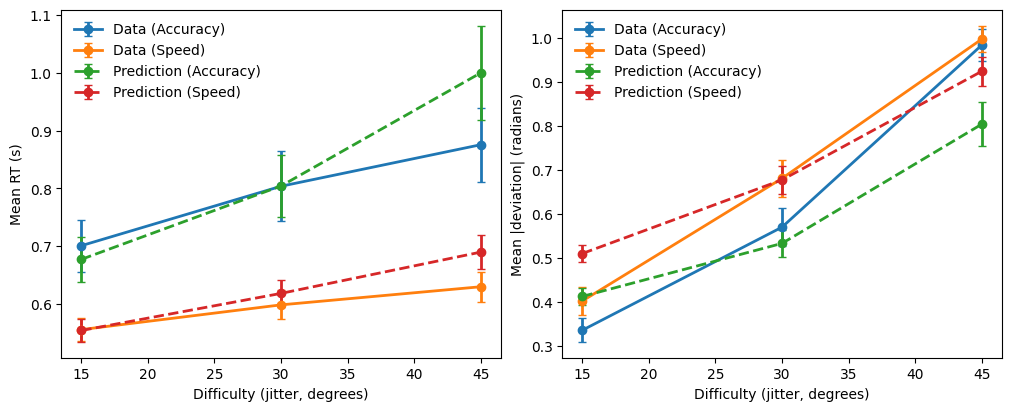

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

plot_metric(axes[0], "rt", "Mean RT (s)")
plot_metric(axes[1], "abs_dev", "Mean |deviation| (radians)")

plt.show()

---

## Notes

- This pattern—mapping design factors to different model parameters—scales to more complex designs
  (e.g., stimulus-specific drifts, participant-level covariates, hierarchical extensions).
- The key idea is to construct **trial-wise parameters** (like `drift_vectors`) and to route trials
  to condition-specific parameters (like thresholds) inside the likelihood.
  
---

## References

Kvam, P. D. (2019). Modeling accuracy, response time, and bias in continuous orientation judgments. *Journal of Experimental Psychology: Human Perception and Performance*, 45(3), 301–318. [https://doi.org/10.1037/xhp0000606](https://doi.org/10.1037/xhp0000606)